In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.special import sici
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels

plt.rcParams.update({
    'font.size': 10,          # base font size
    'axes.labelsize': 10,     # axis label size
    'axes.titlesize': 12,     # title size
    'xtick.labelsize': 9,     
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


----
coefficiente divergenza

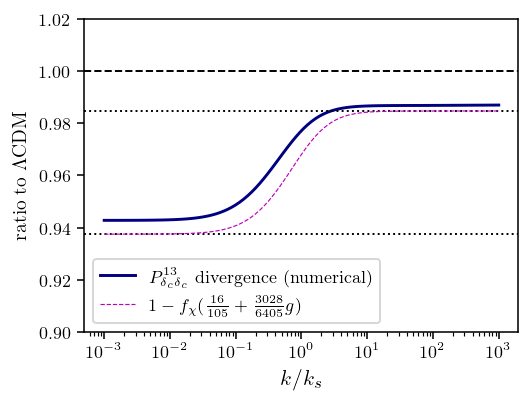

In [ ]:

fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1
supprshift=8
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)

eta, val = np.loadtxt('/home/fverdian/class/soundspeed-scripts/plots4paper/UV-Pcc_F3Data.dat', unpack=True)

div_of_eta = interp1d(eta, val, fill_value='extrapolate')


plt.figure(figsize=(4., 2.9), dpi=140)

Edsdiv = -61/630/np.pi**2
lim1 = (Edsdiv + 0.1* 286/4725/np.pi**2)
lim2 = (Edsdiv + 0.1* 488/33075/np.pi**2)

kvals = np.logspace(-3,3,100)
plt.plot(kvals,div_of_eta(-2*np.log(kvals))/Edsdiv, 'navy', label=r'$P^{13}_{\delta_c\delta_c}$ divergence (numerical)')

plt.axhline(1, color='k', linestyle='--', linewidth=1)
plt.axhline(lim1/Edsdiv, color='k', linestyle=':', linewidth=1)
plt.axhline(lim2/Edsdiv, color='k', linestyle=':', linewidth=1)

plt.plot(kvals,1-0.1*(16/105 + 3028/6405*nk.g_an(-2*np.log(kvals))), 'm--', linewidth=0.6, label=r'$1-f_\chi(\frac{16}{105} + \frac{3028}{6405}g)$')


plt.legend()
plt.ylim([0.9,1.02])
plt.ylabel(r'ratio to $\Lambda$CDM')
plt.xscale('log')
plt.xlabel(r'$k/k_s$', fontsize=11)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/Pcc-UV-divergence.pdf', bbox_inches='tight')
plt.show()

----
Plots from tabellona kernels

In [46]:
fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1
supprshift=8
p=0
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)
def g_ank(k):
    return nk.g_an(-(2+p)*np.log(k/kref))
def h_ank(k):
    return nk.h_an(-(2+p)*np.log(k/kref))

def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

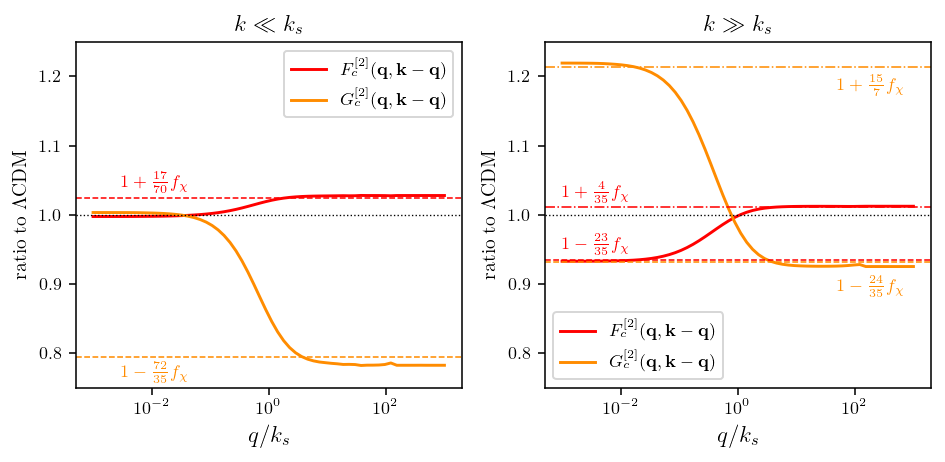

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.85, 3.4), dpi=140)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1/21
qlist=np.logspace(-3,3,60)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12])
    Flist_low.append([F2c,nk.F2_0(kplow,qp,mup), G2_c, nk.g_c_int(-(2+p)*np.log(kplow/kref))*nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax1.plot(qlist,Flist_low[:,2]/Flist_low[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
DeltaF2c_qkMq_limB = (51*fx)/210
ax1.axhline(1+DeltaF2c_qkMq_limB, color='r', linestyle='--', linewidth=0.8)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(1-72/35*fx, color='darkorange', linestyle='--', linewidth=0.8)

ax1.text(3.e-3, 1.04, r'$1+\frac{17}{70}f_\chi$', color='r', fontsize=9)
ax1.text(3.e-3, 0.765, r'$1-\frac{72}{35}f_\chi$', color='darkorange', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim([0.75,1.25])
ax1.set_title(r'$k\ll k_s$', fontsize=12)
ax1.set_ylabel(r'ratio to $\Lambda$CDM')
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_s$', fontsize=12)

kphigh=20
qlist=np.logspace(-3,3,60)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2c,nk.F2_0(kphigh,qp,mup), G2_c, nk.g_c_int(-(2+p)*np.log(kphigh/kref))*nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax2.plot(qlist,Flist_high[:,2]/Flist_high[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')

ax2.axhline(1-23/35*fx, color='r', linestyle='--', linewidth=0.8)
ax2.text(1.e-3, 0.95, r'$1-\frac{23}{35}f_\chi$', color='r', fontsize=9)

ax2.axhline(1+4/35*fx, color='r', linestyle='-.', linewidth=0.8)
ax2.text(1.e-3, 1.025, r'$1+\frac{4}{35}f_\chi$', color='r', fontsize=9)

ax2.axhline(1+15/7*fx, color='darkorange', linestyle='-.', linewidth=0.8)
ax2.text(5.e1, 1.18, r'$1+\frac{15}{7}f_\chi$', color='darkorange', fontsize=9)

ax2.axhline(1-24/35*fx, color='darkorange', linestyle='--', linewidth=0.8)
ax2.text(5.e1, 0.89, r'$1-\frac{24}{35}f_\chi$', color='darkorange', fontsize=9)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend(loc='lower left')
ax2.set_title(r'$k\gg k_s$', fontsize=12)
ax2.set_xscale('log')
ax2.set_ylabel(r'ratio to $\Lambda$CDM')
ax2.set_xlabel(r'$q/k_s$', fontsize=12)
ax2.set_ylim([0.75,1.25])
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2c_qkMq.pdf', bbox_inches='tight')
plt.show()

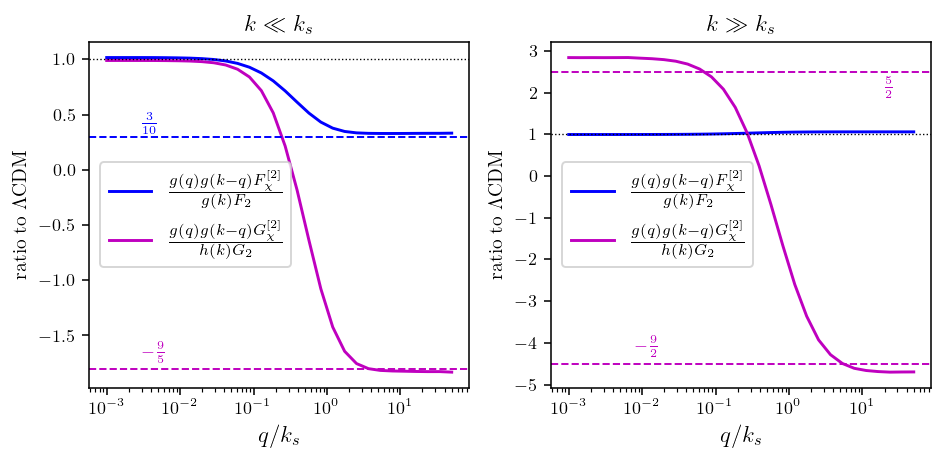

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.85, 3.4), dpi=140)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1/20
qlist=np.logspace(-3,np.log10(50),30)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,_,F2x,G2x= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_low.append([F2x,g_numk(kplow)*nk.F2_0(kplow,qp,mup),G2x,h_numk(kplow)*nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low).T;

# First plot
ax1.plot(qlist,Flist_low[0]/Flist_low[1], 'b', label=r'$\frac{g(q)g(k-q)F_\chi^{[2]}}{g(k)F_2}$')
ax1.plot(qlist,Flist_low[2]/Flist_low[3], 'm', label=r'$\frac{g(q)g(k-q)G_\chi^{[2]}}{h(k)G_2}$')

ax1.axhline(3/10, color='b', linestyle='--', linewidth=1)
ax1.text(3.e-3, 0.38, r'$\frac{3}{10}$', color='b', fontsize=9)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(-9/5, color='m', linestyle='--', linewidth=1)
ax1.text(3.e-3, -1.7, r'$-\frac{9}{5}$', color='m', fontsize=9)
ax1.set_title(r'$k\ll k_s$', fontsize=12)
ax1.set_ylabel(r'ratio to $\Lambda$CDM')
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_s$', fontsize=12)
ax1.legend(fontsize=11, loc='center left')

kphigh=20
qlist=np.logspace(-3,np.log10(50),30)

Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,G2x=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2x, g_numk(kphigh)*nk.F2_0(kphigh,qp,mup), G2x, h_numk(kphigh)*nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high).T

# Second plot
ax2.plot(qlist,Flist_high[0]/Flist_high[1], 'b', label=r'$\frac{g(q)g(k-q)F_\chi^{[2]}}{g(k)F_2}$')
ax2.plot(qlist,Flist_high[2]/Flist_high[3], 'm', label=r'$\frac{g(q)g(k-q)G_\chi^{[2]}}{h(k)G_2}$')

ax2.axhline(2.5, color='m', linestyle='--', linewidth=1)
ax2.text(20, 2., r'$\frac{5}{2}$', color='m', fontsize=9)

ax2.axhline(-4.5, color='m', linestyle='--', linewidth=1)
ax2.text(8.e-3, -4.2, r'$-\frac{9}{2}$', color='m', fontsize=9)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend(fontsize=11, loc='center left')
ax2.set_title(r'$k\gg k_s$', fontsize=12)
ax2.set_xscale('log')
ax2.set_ylabel(r'ratio to $\Lambda$CDM')
ax2.set_xlabel(r'$q/k_s$', fontsize=12)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2chi_qkMq.pdf', bbox_inches='tight')
plt.show()

----
Risultati integrazione numerica

In [2]:
ma=27

kref=8.4e12 * pow(pow(10,-ma)/0.67,1/2) * 0.666**0.25
fx=0.1

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]

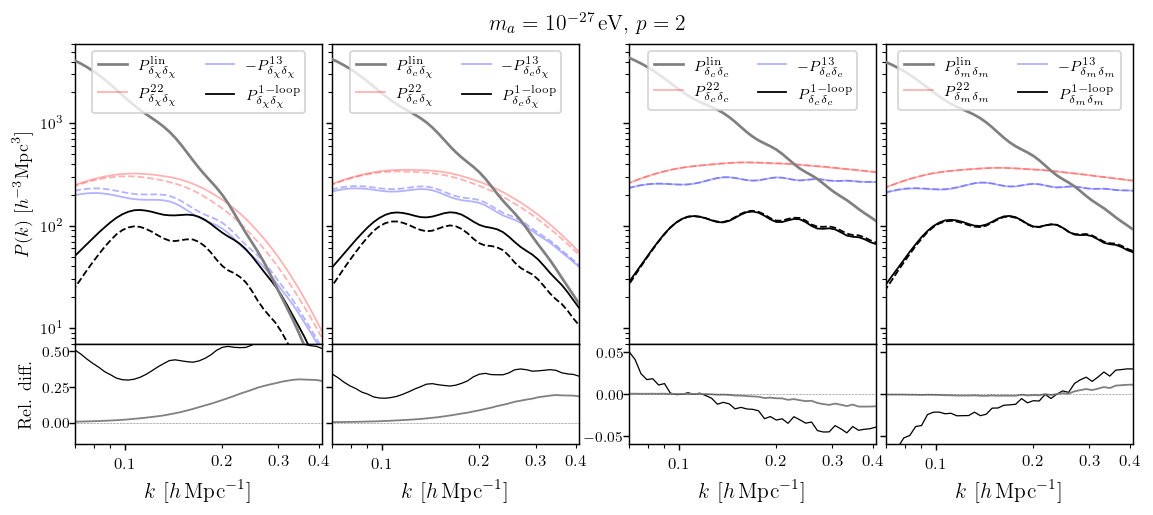

In [4]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2, 5, figsize=(10.5, 4.), dpi=130, gridspec_kw={'height_ratios': [3, 1],'width_ratios': [1,1,0.12,1, 1], 'hspace': 0.0, 'wspace':0.05},)

# ------ delta_chi delta_chi
ax = axs[0,0]
ax.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_\chi\delta_\chi}$', zorder=4)
ax.plot(k, dxdx22, 'r', label=r'$P^{22}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dxdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13, 'b', label=r'$-P^{13}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=10)
# Lower panel (relative differences)
ax = axs[1,0]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22 + dxdx13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')
ax.set_ylabel('Rel. diff.', fontsize=10)

# ------ delta_c delta_chi
ax = axs[0,1]
ax.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13, 'b', label=r'$-P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,1]
relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22 + dcdx13)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_c delta_c
ax = axs[0,3]
ax.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax.plot(k, dcdc22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdc22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13, 'b', label=r'$-P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,3]
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_m delta_m
ax = axs[0,4]
ax.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
ax.plot(k, mm(dcdc22,dcdx22,dxdx22), 'r', label=r'$P^{22}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS) , 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13,dcdx13,dxdx13), 'b', label=r'$-P^{13}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS), 'b--', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,4]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
relative_diff_1l_total = mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-1
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS) - mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')


for ax in axs.flat:
    ax.set_xscale('log')
    ax.set_xlim([0.07,0.41])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.09 else ""))

for i in [0,1,3,4]:
    axs[0,i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0,i].legend(fontsize=8, loc='upper center', ncol=2)
    axs[0,i].set_ylim([7e0,6.e3])
    axs[0,i].set_yscale('log')
    axs[1,i].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
    axs[1,i].set_xlabel(r'$k$ $[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)

for i in [0,1]:
    axs[1,i].set_ylim([-0.15,0.55])
for i in [3,4]:
    axs[1,i].set_ylim([-0.06,0.06])

for com in [(0,1),(1,1),(0,4),(1,4),(0,3)]:
    axs[com].tick_params(axis='y', labelleft=False)
axs[0, 2].axis('off')  # Turn off the top blank subplot
axs[1, 2].axis('off')  # Turn off the bottom blank subplot

axs[0,0].tick_params(axis='y',labelsize=8)  # Y-axis tick labels inside
axs[1,0].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside
axs[1,3].tick_params(axis='y',labelsize=8, pad=-0.1,)  # Y-axis tick labels inside

fig.text(0.5, 0.92, r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$', ha='center', va='center', fontsize=12)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_m27_full.pdf', bbox_inches='tight')

plt.show()

In [5]:
k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/neutrinos/P22-Mnu1p0-N24000-p0.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/neutrinos/P13-Mnu1p0-N16000-p0.txt', unpack=True)[:,:70]

fx=0.02268280069076689

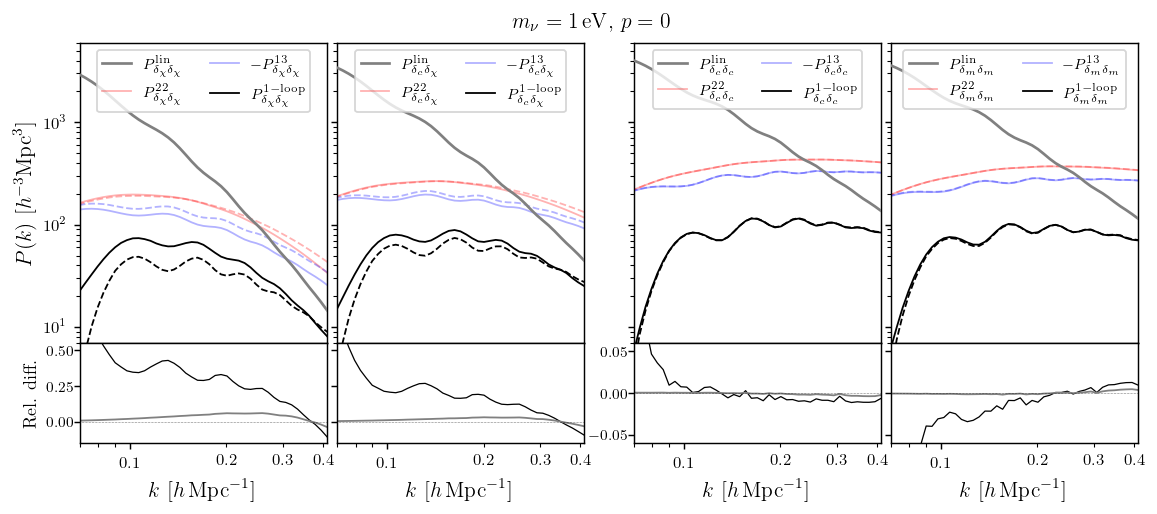

In [6]:


fig, axs = plt.subplots(2, 5, figsize=(10.5, 4.), dpi=130, gridspec_kw={'height_ratios': [3, 1],'width_ratios': [1,1,0.12,1, 1], 'hspace': 0.0, 'wspace':0.05},)

# ------ delta_chi delta_chi
ax = axs[0,0]
ax.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_\chi\delta_\chi}$', zorder=4)
ax.plot(k, dxdx22, 'r', label=r'$P^{22}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dxdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13, 'b', label=r'$-P^{13}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
# Lower panel (relative differences)
ax = axs[1,0]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22 + dxdx13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')
ax.set_ylabel('Rel. diff.', fontsize=10)

# ------ delta_c delta_chi
ax = axs[0,1]
ax.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13, 'b', label=r'$-P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,1]
relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22 + dcdx13)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_c delta_c
ax = axs[0,3]
ax.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax.plot(k, dcdc22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdc22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13, 'b', label=r'$-P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,3]
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_m delta_m
ax = axs[0,4]
ax.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
ax.plot(k, mm(dcdc22,dcdx22,dxdx22), 'r', label=r'$P^{22}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS) , 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13,dcdx13,dxdx13), 'b', label=r'$-P^{13}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS), 'b--', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,4]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
relative_diff_1l_total = mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-1
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS) - mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')


for ax in axs.flat:
    ax.set_xscale('log')
    ax.set_xlim([0.07,0.41])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.09 else ""))

for i in [0,1,3,4]:
    axs[0,i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0,i].legend(fontsize=8, loc='upper center', ncol=2)
    axs[0,i].set_ylim([7e0,6.e3])
    axs[0,i].set_yscale('log')
    axs[1,i].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
    axs[1,i].set_xlabel(r'$k$ $[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)

for i in [0,1]:
    axs[1,i].set_ylim([-0.15,0.55])
for i in [3,4]:
    axs[1,i].set_ylim([-0.06,0.06])

for com in [(0,1),(1,1),(0,4),(1,4),(0,3)]:
    axs[com].tick_params(axis='y', labelleft=False)
axs[0, 2].axis('off')  # Turn off the top blank subplot
axs[1, 2].axis('off')  # Turn off the bottom blank subplot

axs[1,0].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside
axs[1,3].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside


fig.text(0.5, 0.92, r'$m_\nu=1\,\mathrm{eV}$, $p=0$', ha='center', va='center', fontsize=12)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_Mnu0p1_full.pdf', bbox_inches='tight')

plt.show()

---
Figure 1-loop integrals when biased

In [19]:
from scipy.optimize import curve_fit

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
fx=0.02


# Upper panel
bc = 1.5
bx = 0.5

bc2_contr = (bc**2)*(PL_cc +dcdc22 + dcdc13)
bcbx_contr = (2*bc*bx)*(TL_x*PL_cc + dcdx22 + dcdx13)
bx2_contr = (bx**2)*(TL_x**2 * PL_cc +dxdx22 + dxdx13)
Pgg = bc2_contr + bcbx_contr + bx2_contr

bc2_contr_EdS = (bc**2)*(PL_cc +dcdc22_EdS + dcdc13_EdS)
bcbx_contr_EdS = (2*bc*bx)*(TL_x*PL_cc + dcdx22_EdS + dcdx13_EdS)
bx2_contr_EdS = (bx**2)*(TL_x**2 * PL_cc +dxdx22_EdS + dxdx13_EdS)
Pgg_EdS = bc2_contr_EdS + bcbx_contr_EdS + bx2_contr_EdS

kmask = (k<0.4) & (k>0.05)


def func(k, ccx, cxx):
    return (Pgg_EdS[kmask] - ccx * k[kmask]**2 *TL_x[kmask]* PL_cc[kmask]- cxx * k[kmask]**2  *TL_x[kmask]**2 * PL_cc[kmask])


# ERRORBARS PART
Cfull = np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/C_024Q_ngc_z3.txt')
kboss, _, _, _ =  np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/pk_boss_ngc_z3_fkp.txt', unpack=True)
CQ0Q0 = np.diag(Cfull[-78:,-78:])
CQ0_k = interp1d(kboss, CQ0Q0, kind='linear')(k[kmask])

# Fit the curve
popt, pcov = curve_fit(func, k, Pgg[kmask], sigma=CQ0_k)

# Extract the fitted c value
ccx_fitted = popt[0]
cxx_fitted = popt[1]

# Print the fitted c value
print(f"Fitted value for c_cchi: {ccx_fitted} and c_cc: {cxx_fitted}")

reldifforig = (Pgg-Pgg_EdS)
reldifffitted = (func(k, ccx_fitted,cxx_fitted) - Pgg[kmask])



Fitted value for c_cchi: -5.8605444282648085 and c_cc: -0.7447352240478574


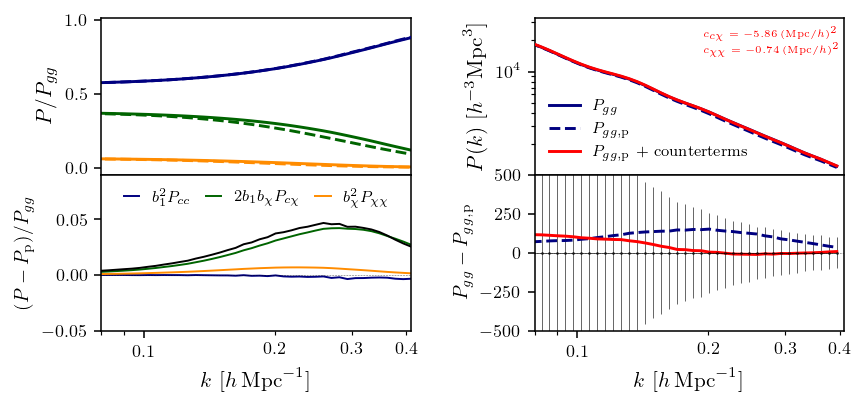

In [60]:
fig, axs = plt.subplots(2, 2, figsize=(6.85, 2.9), dpi=140, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.0, 'wspace': 0.4})

# Upper left panel (ax1)
axs[0, 0].plot(k, bc2_contr / Pgg, 'navy', label=r'$b_1^2 P_{cc}$')
axs[0, 0].plot(k, bcbx_contr / Pgg, 'darkgreen', label=r'$2b_1b_\chi P_{c\chi}$')
axs[0, 0].plot(k, bx2_contr / Pgg, 'darkorange', linewidth=1.5, label=r'$b_\chi^2 P_{\chi\chi}$')

axs[0, 0].plot(k, bc2_contr_EdS/Pgg, 'navy',linestyle='--', zorder=4)
axs[0, 0].plot(k, bcbx_contr_EdS/Pgg, 'darkgreen',linestyle='--', zorder=4)
axs[0, 0].plot(k, bx2_contr_EdS/Pgg, 'darkorange', linestyle='--', zorder=4)



axs[0, 0].set_ylabel(r'$P/P_{gg}$', fontsize=11)
axs[0, 0].set_xscale('log')



# Lower left panel (ax2)
axs[1, 0].plot(k, (bc2_contr - bc2_contr_EdS) / Pgg, 'navy', linewidth=1., linestyle='-', label=r'$b_1^2 P_{cc}$')
axs[1, 0].plot(k, (bcbx_contr - bcbx_contr_EdS) / Pgg, 'darkgreen', linewidth=1., linestyle='-', label=r'$2b_1b_\chi P_{c\chi}$')
axs[1, 0].plot(k, (bx2_contr - bx2_contr_EdS) / Pgg, 'darkorange', linewidth=1., linestyle='-', label=r'$b_\chi^2 P_{\chi\chi}$')
axs[1, 0].plot(k, (Pgg - Pgg_EdS) / Pgg, 'k', linewidth=1., linestyle='-')
axs[1, 0].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
axs[1, 0].set_ylim([-0.05, 0.09])
axs[1, 0].set_xscale('log')

axs[1, 0].legend(fontsize=8, loc='upper center',  handlelength=1, columnspacing=1., ncol=3, frameon=False)

axs[1, 0].set_xlabel(r'$k$ $[h\,\mathrm{Mpc}^{-1}]$', fontsize=11)
axs[1, 0].set_ylabel(r'$(P-P_\mathrm{p})/P_{gg}$', fontsize=10)

axs[0, 0].set_xlim([0.08, 0.41])
axs[1, 0].set_xlim([0.08, 0.41])

# Upper right panel (ax3)
axs[0, 1].plot(k[kmask], Pgg[kmask], 'navy', linewidth=1.5, label=r'$P_{gg}$')
axs[0, 1].plot(k[kmask], Pgg_EdS[kmask], 'navy', linestyle='--', linewidth=1.5, label=r'$P_{gg,\mathrm{p}}$')
axs[0, 1].plot(k[kmask], func(k, ccx_fitted, cxx_fitted), 'red', linestyle='-', linewidth=1.5, label=r'$P_{gg,\mathrm{p}}$ + counterterms', zorder=10)

axs[0, 1].legend(fontsize=8, loc='lower left',frameon=False)
axs[0, 1].set_xscale('log')
axs[0, 1].set_yscale('log')
axs[0, 1].set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=11)
axs[0, 1].tick_params(axis='x', labelbottom=False)
axs[0, 1].text(0.195, 2.7e4, r'$c_{c\chi}='+f'{ccx_fitted:.2f}'+r'\,(\mathrm{Mpc}/h)^2$'+'\n'+r'$c_{\chi\chi}='+f'{cxx_fitted:.2f}'+r'\,(\mathrm{Mpc}/h)^2$', ha='left', va='top', fontsize=5, color='red')


# Lower right panel (ax4)
axs[1, 1].errorbar(k[kmask], np.zeros_like(CQ0_k), yerr=np.sqrt(CQ0_k), color='k', linewidth=0.3, marker='o', markersize=0.3)
axs[1, 1].plot(k[kmask], reldifforig[kmask], 'navy', linestyle='--', linewidth=1.5)
axs[1, 1].plot(k[kmask], reldifffitted, 'r', linestyle='-', linewidth=1.5)
axs[1, 1].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
axs[1, 1].set_ylim([-500, 500])
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel(r'$k$ $[h\,\mathrm{Mpc}^{-1}]$', fontsize=11)
axs[1, 1].set_ylabel(r'$P_{gg}-P_{gg,\mathrm{p}}$', fontsize=10)

axs[0, 1].set_xlim([0.08, 0.41])
axs[1, 1].set_xlim([0.08, 0.41])

axs[0, 0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs[0, 1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

for ax in [axs[1,0], axs[1, 1]]:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.095 else ""))

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/Pgg_prescription_breakdown_fit.pdf', bbox_inches='tight')

plt.show()